# DNN Model for Text Classification

This notebook handles the entire pipeline for training a DNN model on text data:
1. Data loading and preprocessing
2. Feature extraction
3. Hyperparameter tuning
4. Model training and evaluation
5. Model saving


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import keras_tuner as kt
import os

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

np.random.seed(2025)
tf.random.set_seed(2025)


2025-03-27 17:04:27.224491: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-27 17:04:27.238028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743095067.255663   78556 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743095067.260481   78556 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-27 17:04:27.278674: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Data Preparation

In [3]:
print("Loading dataset...")
df = pd.read_csv("../../datasets/custom_dataset.csv", sep="\t")
print(f"Dataset shape: {df.shape}")
df.head()


Loading dataset...
Dataset shape: (5437, 2)


,Text,Label
0,"In mechanics, a variable-mass system is a coll...",Human
1,Variable-mass systems in fluids involve object...,AI
2,"Geomechanics (from the Greek γεός, i.e. prefix...",Human
3,Geomechanics studies the mechanical behavior o...,AI
4,Microscale chemistry (often referred to as sma...,Human


In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+\.\S+", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)

df[['Text', 'cleaned_text']].sample(5)


,Text,cleaned_text
23,"A banked turn, in fluid dynamics, describes th...","a banked turn, in fluid dynamics, describes th..."
531,"In fluid mechanics, a couple describes a pair ...","in fluid mechanics, a couple describes a pair ..."
5398,Reconciliation ecology bridges the gap between...,reconciliation ecology bridges the gap between...
5170,Systems immunology investigates the immune sys...,systems immunology investigates the immune sys...
855,Proofreading in biology refers to the cellular...,proofreading in biology refers to the cellular...


In [5]:
def extract_features(texts):
    print("Extracting features...")
    features = []
    stop_words = set(stopwords.words("english"))
    
    for text in texts:
        if not isinstance(text, str) or not text.strip():
            features.append([0] * 8)
            continue
            
        words = word_tokenize(text)
        
        if not words:
            features.append([0] * 8)
            continue
            
        num_words = len(words)
        num_chars = len(text)
        avg_word_length = np.mean([len(w) for w in words]) if words else 0
        num_stopwords = sum(1 for word in words if word.lower() in stop_words)
        stopword_ratio = num_stopwords / num_words if num_words else 0
        
        num_punctuation = sum(1 for char in text if char in string.punctuation)
        punctuation_ratio = num_punctuation / num_chars if num_chars else 0
        
        lexical_diversity = len(set(words)) / num_words if num_words else 0
        
        feature_vector = [
            num_words,
            num_chars,
            avg_word_length,
            num_stopwords,
            stopword_ratio,
            num_punctuation,
            punctuation_ratio,
            lexical_diversity
        ]
        
        features.append(feature_vector)
        
    return np.array(features)

features = extract_features(df['cleaned_text'].values)

labels = df['Label'].apply(lambda x: 0 if x == 'Human' else 1).values

print(f"Feature shape: {features.shape}")
print(f"Label distribution: {pd.Series(labels).value_counts().to_dict()}")

X_train, X_temp, y_train, y_temp = train_test_split(
    features, labels, test_size=0.3, random_state=2025, stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=2025, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Extracting features...
Feature shape: (5437, 8)
Label distribution: {1: 3461, 0: 1976}
Training set: 3805 samples
Validation set: 816 samples
Test set: 816 samples


## Model Development

In [ ]:
def build_dnn_model(hp):
    model = keras.Sequential()
    
    model.add(layers.Input(shape=(X_train.shape[1],)))
    
    for i in range(hp.Int('num_layers', 1, 4)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=8, max_value=256, step=16),
            activation='relu'
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)))
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
        ),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(), keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return model

tuner = kt.Hyperband(
    build_dnn_model,
    objective='val_accuracy',
    max_epochs=25,
    factor=3,
    seed=2025,
    directory='../../tuner_results',
    project_name='dnn_model'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

tuner.search(
    X_train, y_train,
    epochs=25,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters: {best_hps.values}")


Trial 90 Complete [00h 00m 10s]
val_accuracy: 0.8848039507865906

Best val_accuracy So Far: 0.9338235259056091
Total elapsed time: 00h 09m 35s
Best hyperparameters: {'num_layers': 4, 'units_0': 216, 'dropout_0': 0.1, 'learning_rate': 0.00019367160344936564, 'units_1': 88, 'dropout_1': 0.1, 'units_2': 216, 'dropout_2': 0.4, 'units_3': 152, 'dropout_3': 0.1, 'units_4': 120, 'dropout_4': 0.30000000000000004, 'tuner/epochs': 50, 'tuner/initial_epoch': 17, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0068'}


Epoch 1/100
105/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7823 - auc_3: 0.8572 - loss: 0.4666 - precision_3: 0.8598 - recall_3: 0.7848

119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7906 - auc_3: 0.8646 - loss: 0.4541 - precision_3: 0.8647 - recall_3: 0.7938 - val_accuracy: 0.6900 - val_auc_3: 0.9579 - val_loss: 0.5787 - val_precision_3: 0.6727 - val_recall_3: 1.0000 - learning_rate: 1.9367e-04
Epoch 2/100
118/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8866 - auc_3: 0.9412 - loss: 0.2952 - precision_3: 0.9043 - recall_3: 0.9189

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8866 - auc_3: 0.9413 - loss: 0.2951 - precision_3: 0.9044 - recall_3: 0.9189 - val_accuracy: 0.8799 - val_auc_3: 0.9765 - val_loss: 0.2758 - val_precision_3: 0.8505 - val_recall_3: 0.9846 - learning_rate: 1.9367e-04
Epoch 3/100
113/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8923 - auc_3: 0.9481 - loss: 0.2768 - precision_3: 0.9094 - recall_3: 0.9231

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8924 - auc_3: 0.9482 - loss: 0.2766 - precision_3: 0.9094 - recall_3: 0.9234 - val_accuracy: 0.9093 - val_auc_3: 0.9737 - val_loss: 0.2309 - val_precision_3: 0.8968 - val_recall_3: 0.9692 - learning_rate: 1.9367e-04
Epoch 4/100
105/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9005 - auc_3: 0.9490 - loss: 0.2722 - precision_3: 0.9088 - recall_3: 0.9380

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9006 - auc_3: 0.9494 - loss: 0.2712 - precision_3: 0.9089 - recall_3: 0.9378 - val_accuracy: 0.9154 - val_auc_3: 0.9793 - val_loss: 0.2017 - val_precision_3: 0.9034 - val_recall_3: 0.9712 - learning_rate: 1.9367e-04
Epoch 5/100
113/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8888 - auc_3: 0.9483 - loss: 0.2779 - precision_3: 0.9021 - recall_3: 0.9258

...

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9013 - auc_3: 0.9539 - loss: 0.2581 - precision_3: 0.9106 - recall_3: 0.9369 - val_accuracy: 0.9240 - val_auc_3: 0.9800 - val_loss: 0.1915 - val_precision_3: 0.9210 - val_recall_3: 0.9635 - learning_rate: 1.9367e-04
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8969 - auc_3: 0.9544 - loss: 0.2591 - precision_3: 0.9107 - recall_3: 0.9292 - val_accuracy: 0.9240 - val_auc_3: 0.9776 - val_loss: 0.2018 - val_precision_3: 0.9305 - val_recall_3: 0.9519 - learning_rate: 1.9367e-04
Epoch 9/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8990 - auc_3: 0.9560 - loss: 0.2510 - precision_3: 0.9085 - recall_3: 0.9356 - val_accuracy: 0.9167 - val_auc_3: 0.9786 - val_loss: 0.2008 - val_precision_3: 0.9431 - val_recall_3: 0.9250 - learning_rate: 1.9367e-04
Epoch 10/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8976 - auc_3: 0.9578 - loss: 0.2497 - precision_3: 0.9062 - recall_3: 0.9360 - val_accuracy: 0.

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9020 - auc_3: 0.9585 - loss: 0.2459 - precision_3: 0.9169 - recall_3: 0.9302 - val_accuracy: 0.9228 - val_auc_3: 0.9800 - val_loss: 0.1863 - val_precision_3: 0.9489 - val_recall_3: 0.9288 - learning_rate: 9.6836e-05
Epoch 12/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9011 - auc_3: 0.9594 - loss: 0.2460 - precision_3: 0.9123 - recall_3: 0.9343 - val_accuracy: 0.9252 - val_auc_3: 0.9797 - val_loss: 0.1923 - val_precision_3: 0.9422 - val_recall_3: 0.9404 - learning_rate: 9.6836e-05
Epoch 13/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9069 - auc_3: 0.9568 - loss: 0.2520 - precision_3: 0.9166 - recall_3: 0.9390 - val_accuracy: 0.9216 - val_auc_3: 0.9806 - val_loss: 0.1904 - val_precision_3: 0.9086 - val_recall_3: 0.9750 - learning_rate: 9.6836e-05
Epoch 14/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9046 - auc_3: 0.9609 - loss: 0.2377 - precision_3: 0.9124 - recall_3: 0.9403 - val_accuracy: 

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9065 - auc_3: 0.9597 - loss: 0.2420 - precision_3: 0.9164 - recall_3: 0.9387 - val_accuracy: 0.9265 - val_auc_3: 0.9810 - val_loss: 0.1834 - val_precision_3: 0.9389 - val_recall_3: 0.9462 - learning_rate: 4.8418e-05
Epoch 16/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8978 - auc_3: 0.9576 - loss: 0.2491 - precision_3: 0.9135 - recall_3: 0.9275 - val_accuracy: 0.9265 - val_auc_3: 0.9812 - val_loss: 0.1834 - val_precision_3: 0.9307 - val_recall_3: 0.9558 - learning_rate: 4.8418e-05
Epoch 17/100
105/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9106 - auc_3: 0.9591 - loss: 0.2433 - precision_3: 0.9173 - recall_3: 0.9447

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9106 - auc_3: 0.9593 - loss: 0.2429 - precision_3: 0.9174 - recall_3: 0.9443 - val_accuracy: 0.9265 - val_auc_3: 0.9810 - val_loss: 0.1823 - val_precision_3: 0.9356 - val_recall_3: 0.9500 - learning_rate: 4.8418e-05
Epoch 18/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9038 - auc_3: 0.9602 - loss: 0.2425 - precision_3: 0.9143 - recall_3: 0.9367 - val_accuracy: 0.9252 - val_auc_3: 0.9811 - val_loss: 0.1863 - val_precision_3: 0.9474 - val_recall_3: 0.9346 - learning_rate: 4.8418e-05
Epoch 19/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9002 - auc_3: 0.9595 - loss: 0.2416 - precision_3: 0.9091 - recall_3: 0.9368 - val_accuracy: 0.9277 - val_auc_3: 0.9808 - val_loss: 0.1851 - val_precision_3: 0.9407 - val_recall_3: 0.9462 - learning_rate: 4.8418e-05
Epoch 20/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9058 - auc_3: 0.9587 - loss: 0.2455 - precision_3: 0.9220 - recall_3: 0.9308 - val_accuracy: 

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8994 - auc_3: 0.9586 - loss: 0.2447 - precision_3: 0.9133 - recall_3: 0.9302 - val_accuracy: 0.9301 - val_auc_3: 0.9811 - val_loss: 0.1817 - val_precision_3: 0.9376 - val_recall_3: 0.9538 - learning_rate: 2.4209e-05
Epoch 22/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9015 - auc_3: 0.9590 - loss: 0.2460 - precision_3: 0.9167 - recall_3: 0.9300 - val_accuracy: 0.9301 - val_auc_3: 0.9810 - val_loss: 0.1833 - val_precision_3: 0.9343 - val_recall_3: 0.9577 - learning_rate: 2.4209e-05
Epoch 23/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9080 - auc_3: 0.9608 - loss: 0.2363 - precision_3: 0.9194 - recall_3: 0.9376 - val_accuracy: 0.9252 - val_auc_3: 0.9813 - val_loss: 0.1830 - val_precision_3: 0.9274 - val_recall_3: 0.9577 - learning_rate: 2.4209e-05
Epoch 24/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9060 - auc_3: 0.9606 - loss: 0.2404 - precision_3: 0.9158 - recall_3: 0.9385 - val_accuracy: 

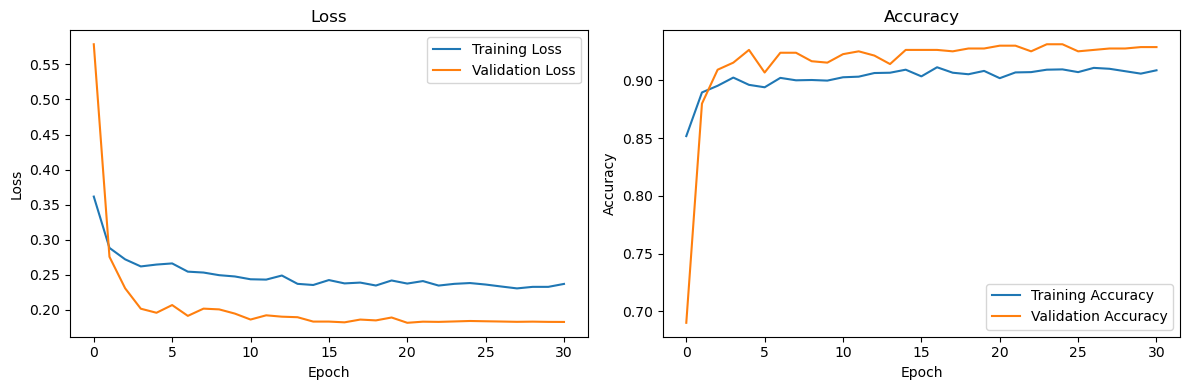

In [7]:
model = tuner.hypermodel.build(best_hps)


callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('../../trained_models/tensorflow/dnn_model.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Model Evaluation

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9155 - auc_3: 0.9695 - loss: 0.2086 - precision_3: 0.9223 - recall_3: 0.9459   
Test accuracy: 0.9265
Test AUC: 0.9729
Test precision: 0.9306
Test recall: 0.9557
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


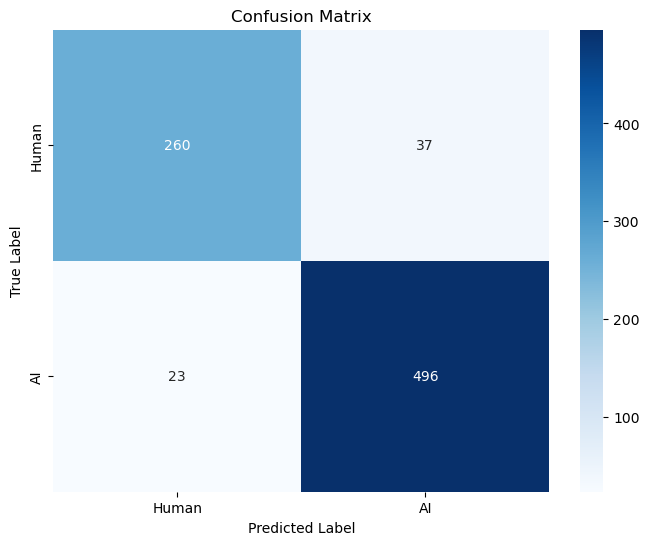

Classification Report:
              precision    recall  f1-score   support

       Human       0.92      0.88      0.90       297
          AI       0.93      0.96      0.94       519

    accuracy                           0.93       816
   macro avg       0.92      0.92      0.92       816
weighted avg       0.93      0.93      0.93       816



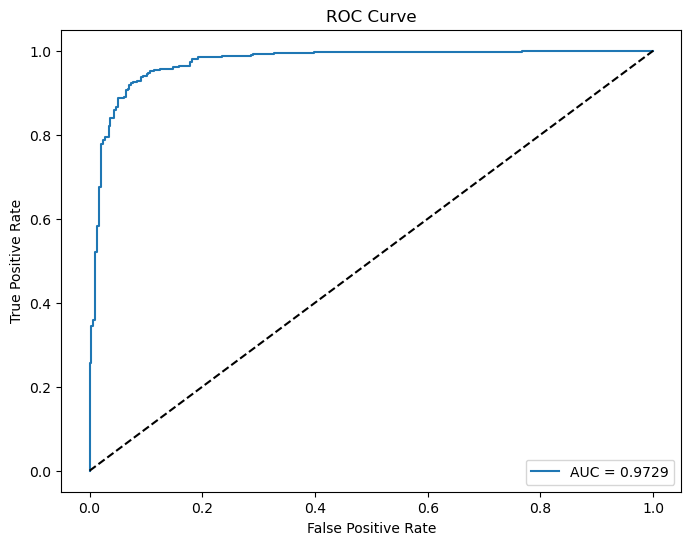

In [8]:
model = keras.models.load_model('../../trained_models/tensorflow/dnn_model.h5')

test_loss, test_acc, test_auc, test_precision, test_recall = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Human', 'AI'],
    yticklabels=['Human', 'AI']
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


## Model Deployment

In [ ]:
model.save('../../trained_models/tensorflow/dnn_model.h5')
print("Model saved to 'trained_models/tensorflow/dnn_model.h5'")

import pickle

with open('../../trained_models/tensorflow/dnn_tokenizer', 'wb') as f:
    pickle.dump({
        'extract_features': extract_features,
        'clean_text': clean_text
    }, f)
print("Feature extractor saved to 'trained_models/tensorflow/dnn_tokenizer'")

def predict_text(text, model, feature_extractor):
    cleaned_text = feature_extractor['clean_text'](text)
    
    features = feature_extractor['extract_features']([cleaned_text])
    
    prediction = model.predict(features)[0][0]
    
    return {
        'probability': float(prediction),
        'prediction': 'AI' if prediction > 0.5 else 'Human'
    }

loaded_model = keras.models.load_model('../../trained_models/tensorflow/dnn_model.h5')
with open('../../trained_models/tensorflow/dnn_tokenizer', 'rb') as f:
    loaded_extractor = pickle.load(f)

sample_text = "This is a sample text to test the model."
result = predict_text(sample_text, loaded_model, loaded_extractor)
print(f"Sample text: '{sample_text}'")
print(f"Prediction: {result['prediction']}")


Model saved to 'trained_models/tensorflow/dnn_model.h5'
Feature extractor saved to 'trained_models/tensorflow/feature_extractor.pkl'


Extracting features...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Sample text: 'This is a sample text to test the model.'
Prediction: Human
